# Vacational rentals in the Canary Islands

**Dataset**: Registro General Turistico de Canarias

**Source**: [Consejeria de Turismo y Empleo](https://datos.canarias.es)

**Question**: How are the 73k+ registered vacational rentals distributed across islands and municipalities?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
OUTPUT_DIR = Path("output/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = "/home/gabry/dev/dataciviclab-workspace/canarias-analisis/data/raw/establecimientos-extrahoteleros-de-tipologia-vivienda-vacacional-inscritos-en-el-registro-genera.csv"
df = pd.read_csv(CSV_PATH, sep=";", low_memory=False)
print("Properties:", len(df), "| Columns:", len(df.columns))
df.head(2)

Properties: 73541 | Columns: 16


,establecimiento_id,establecimiento_nombre_comercial,establecimiento_modalidad,establecimiento_tipologia,establecimiento_clasificacion,direccion,direccion_isla_nombre,direccion_provincia_nombre,direccion_municipio_nombre,direccion_localidad_nombre,direccion_codigo_postal,numero_dormitorios_individuales_explotacion,numero_dormitorios_dobles_explotacion,plazas,longitud,latitud
0,A-38-4-0000685,Casa Tinali,Extrahotelera,Vivienda Vacacional,Categoria Unica,C/. Oroteanda Baja Nº 14,Tenerife,Santa Cruz De Tenerife,San Miguel De Abona,San Miguel De Abona,38639,0.0,0.0,10,-16.636038,28.044253
1,A-38-4-0000719,La Casita De La Playa,Extrahotelera,Vivienda Vacacional,Categoria Unica,"Paseo De La Playa, 4 4",Tenerife,Santa Cruz De Tenerife,Santa Cruz Tenerife,Santa Cruz De Tenerife,38140,0.0,0.0,2,-16.152085,28.523419


In [2]:
# Clean
df = df[df["direccion_isla_nombre"] != "_U"]
df["island"] = df["direccion_isla_nombre"]
df["plazas"] = pd.to_numeric(df["plazas"], errors="coerce")

island_counts = df.groupby("island").size().sort_values(ascending=False)
print("Properties per island:")
print(island_counts)
print("Total:", len(df))
print("Total beds:", int(df["plazas"].sum()))
print("Avg plazas per property:", round(df["plazas"].mean(), 1))

Properties per island:
island
Tenerife         30851
Gran Canaria     17092
Lanzarote        11041
Fuerteventura    10180
La Palma          2291
La Gomera         1310
El Hierro          688
dtype: int64
Total: 73453
Total beds: 312014


Avg plazas per property: 4.2


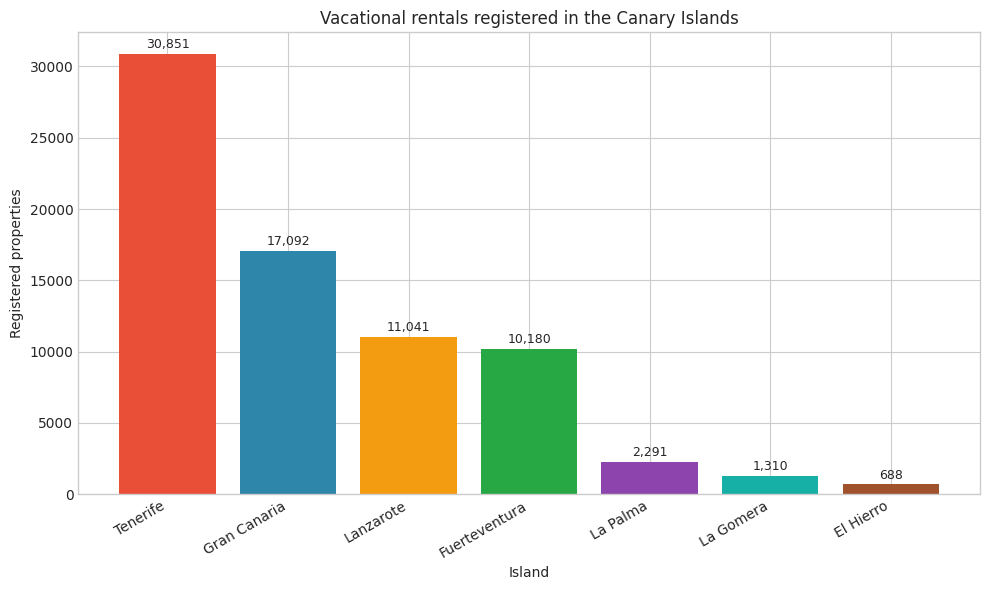

Saved


In [3]:
# 1. Bar chart by island
colors_islands = {
    "Tenerife": "#E94F37",
    "Gran Canaria": "#2E86AB",
    "Lanzarote": "#F39C12",
    "Fuerteventura": "#28A745",
    "La Palma": "#8E44AD",
    "La Gomera": "#17B0A7",
    "El Hierro": "#A0522D"
}

fig, ax = plt.subplots(figsize=(10, 6))
islands = island_counts.index.tolist()
bars = ax.bar(islands, island_counts.values, color=[colors_islands.get(i, "#555") for i in islands])
ax.set_xlabel("Island")
ax.set_ylabel("Registered properties")
ax.set_title("Vacational rentals registered in the Canary Islands")
for bar, val in zip(bars, island_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200, f"{val:,}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "vacational_rentals_by_island.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved")

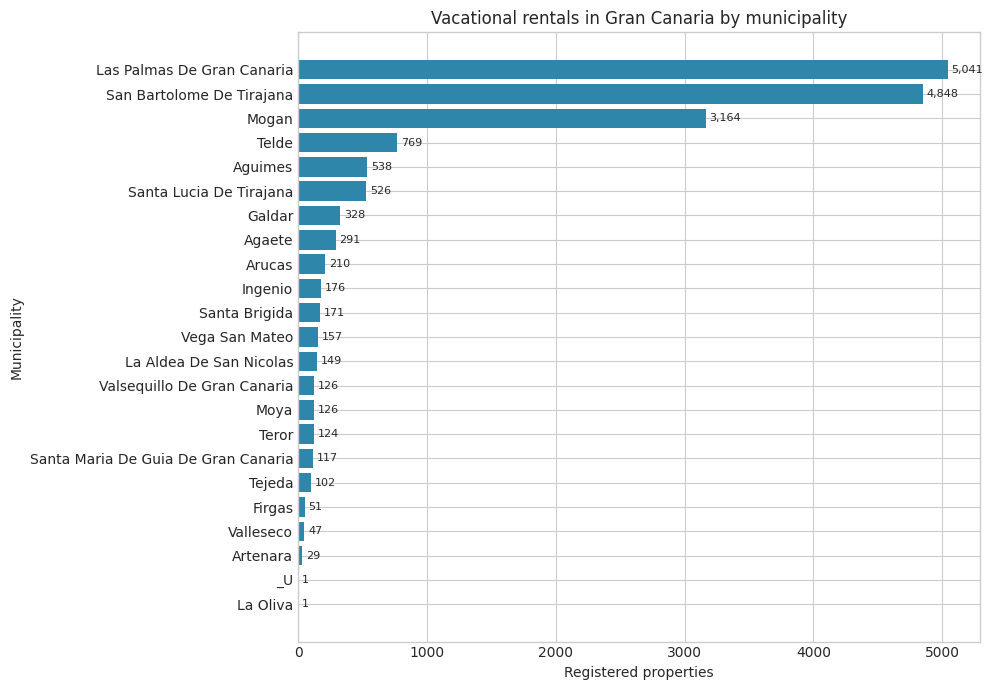

Saved


In [4]:
# 2. Gran Canaria municipalities
fig, ax = plt.subplots(figsize=(10, 7))
gc = df[df["island"] == "Gran Canaria"]
gc_mun = gc.groupby("direccion_municipio_nombre").size().sort_values(ascending=True)
ax.barh(gc_mun.index, gc_mun.values, color="#2E86AB")
ax.set_xlabel("Registered properties")
ax.set_ylabel("Municipality")
ax.set_title("Vacational rentals in Gran Canaria by municipality")
ax.set_xlim(0, None)
for i, (idx, val) in enumerate(gc_mun.items()):
    ax.text(val + 30, i, f"{val:,}", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "vacational_rentals_gran_canaria_municipalities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved")

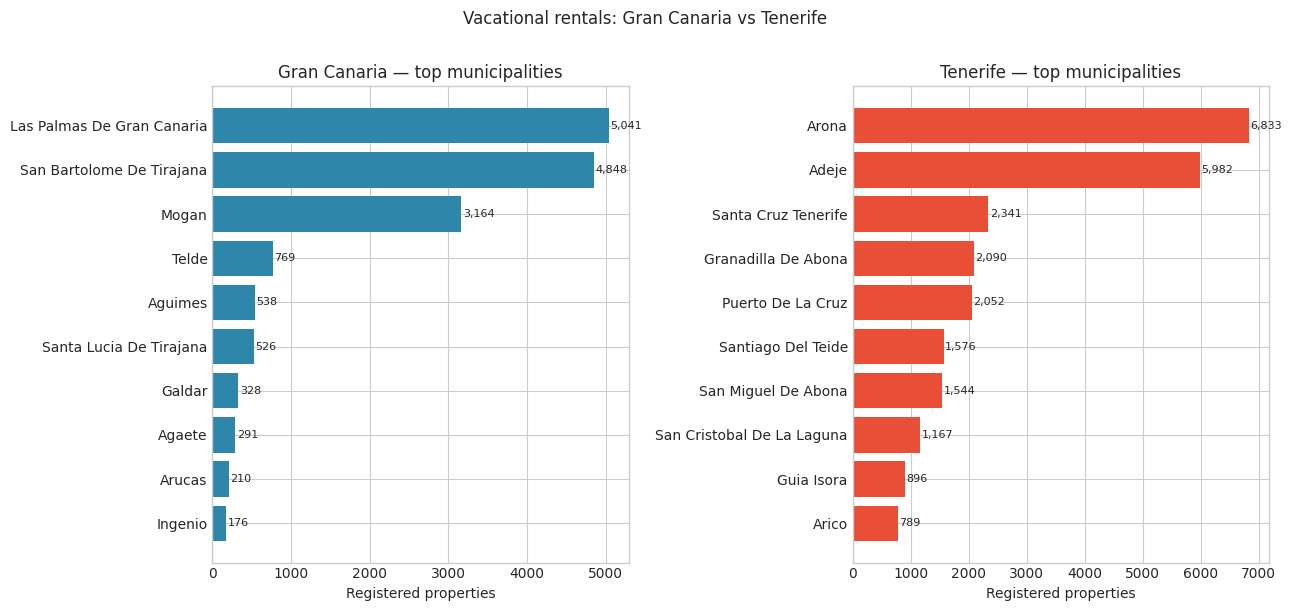

Saved


In [5]:
# 3. Gran Canaria vs Tenerife — top 10 municipalities each
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, island in zip(axes, ["Gran Canaria", "Tenerife"]):
    data = df[df["island"] == island]
    mun = data.groupby("direccion_municipio_nombre").size().sort_values(ascending=True).tail(10)
    color = "#2E86AB" if island == "Gran Canaria" else "#E94F37"
    ax.barh(mun.index, mun.values, color=color)
    ax.set_xlabel("Registered properties")
    ax.set_title(island + " — top municipalities")
    ax.set_xlim(0, None)
    for i, (idx, val) in enumerate(mun.items()):
        ax.text(val + 20, i, f"{val:,}", va="center", fontsize=8)

fig.suptitle("Vacational rentals: Gran Canaria vs Tenerife", y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "vacational_rentals_gc_vs_tenerife.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved")

In [6]:
# 4. Top municipalities overall
print("Top 5 municipalities:")
mun_all = df.groupby(["island", "direccion_municipio_nombre"]).size().reset_index(name="total")
mun_all = mun_all.sort_values("total", ascending=False).head(5)
for _, row in mun_all.iterrows():
    print("  " + row["island"] + " / " + row["direccion_municipio_nombre"] + ": " + str(row["total"]))

Top 5 municipalities:
  Tenerife / Arona: 6833
  Tenerife / Adeje: 5982
  Fuerteventura / La Oliva: 5401
  Gran Canaria / Las Palmas De Gran Canaria: 5041
  Gran Canaria / San Bartolome De Tirajana: 4848
